Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
df.shape

(918, 12)

In [6]:
X = df.drop("HeartDisease", axis=1)


In [7]:
X = pd.get_dummies(X, drop_first=True)

print(X.head())

   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  Sex_M  \
0   40        140          289          0    172      0.0   True   
1   49        160          180          0    156      1.0  False   
2   37        130          283          0     98      0.0   True   
3   48        138          214          0    108      1.5  False   
4   54        150          195          0    122      0.0   True   

   ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  RestingECG_Normal  \
0               True              False             False               True   
1              False               True             False               True   
2               True              False             False              False   
3              False              False             False               True   
4              False               True             False               True   

   RestingECG_ST  ExerciseAngina_Y  ST_Slope_Flat  ST_Slope_Up  
0          False             False          F

In [8]:
X = X.astype(int)

print(X.head())

   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  Sex_M  \
0   40        140          289          0    172        0      1   
1   49        160          180          0    156        1      0   
2   37        130          283          0     98        0      1   
3   48        138          214          0    108        1      0   
4   54        150          195          0    122        0      1   

   ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  RestingECG_Normal  \
0                  1                  0                 0                  1   
1                  0                  1                 0                  1   
2                  1                  0                 0                  0   
3                  0                  0                 0                  1   
4                  0                  1                 0                  1   

   RestingECG_ST  ExerciseAngina_Y  ST_Slope_Flat  ST_Slope_Up  
0              0                 0           

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.4331398   0.41090889  0.82507026 -0.55134134  1.38292822 -0.72759199
   0.51595242  2.07517671 -0.53283777 -0.22967867  0.81427482 -0.49044933
  -0.8235563  -1.00218103  1.15067399]
 [-0.47848359  1.49175234 -0.17196105 -0.55134134  0.75415714  0.28289129
  -1.93816322 -0.48188667  1.87674385 -0.22967867  0.81427482 -0.49044933
  -0.8235563   0.99782372 -0.86905588]
 [-1.75135854 -0.12951283  0.7701878  -0.55134134 -1.52513802 -0.72759199
   0.51595242  2.07517671 -0.53283777 -0.22967867 -1.22808661  2.03894663
  -0.8235563  -1.00218103  1.15067399]
 [-0.5845565   0.30282455  0.13903954 -0.55134134 -1.13215609  0.28289129
  -1.93816322 -0.48188667 -0.53283777 -0.22967867  0.81427482 -0.49044933
   1.21424608  0.99782372 -0.86905588]
 [ 0.05188098  0.95133062 -0.0347549  -0.55134134 -0.5819814  -0.72759199
   0.51595242 -0.48188667  1.87674385 -0.22967867  0.81427482 -0.49044933
  -0.8235563  -1.00218103  1.15067399]]


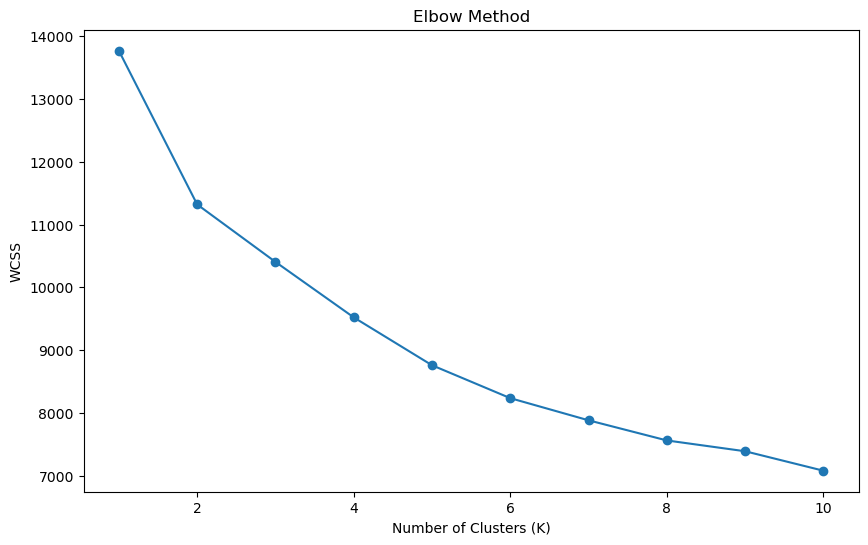

In [10]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10,6))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [11]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print(df.head())

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  Cluster  
0              N      0.0       Up             0        0  
1              N      1.0     Flat             1        1  
2              N      0.0       Up             0        0  
3              Y      1.5     Flat             1        1  
4              N      0.0       Up             0        0  


In [12]:
print(df.select_dtypes(include='number').groupby(df['Cluster']).mean())

               Age   RestingBP  Cholesterol  FastingBS       MaxHR   Oldpeak  \
Cluster                                                                        
0        49.637255  129.254902   218.431373   0.129902  150.703431  0.278922   
1        56.609804  134.909804   183.094118   0.315686  125.694118  1.374118   

         HeartDisease  Cluster  
Cluster                         
0            0.176471      0.0  
1            0.854902      1.0  


In [13]:
kmeans.inertia_

11321.04536729605

In [14]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

print("Inertia:", kmeans.inertia_)

Inertia: 11321.04536729605
